In [1]:
library(cooccur)

# Demo on built in dataset

[1] 13 17
                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


[1] 13 17
                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


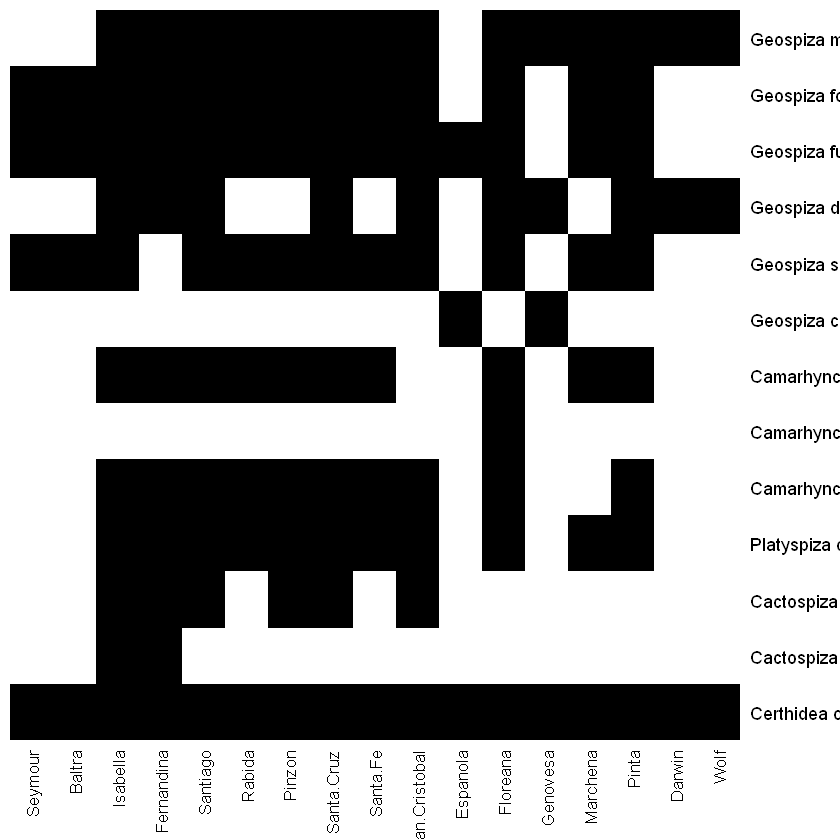

In [50]:
data(finches)
df <- finches

print(dim(df))
print(df[1:10, 1:5])

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [59]:

result <- cooccur(mat = df,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE)   # use species names

summary(result)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = finches, type = "spp_site", thresh = TRUE, spp_names = TRUE)

Of 78 species pair combinations, 14 pairs (17.95 %) were removed from the analysis because expected co-occurrence was < 1 and 64 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          13.0           17.0           14.0            1.0           42.0 
Unclassifiable Non-random (%) 
           7.0           23.4 
attr(,"class")
[1] "summary.cooccur"

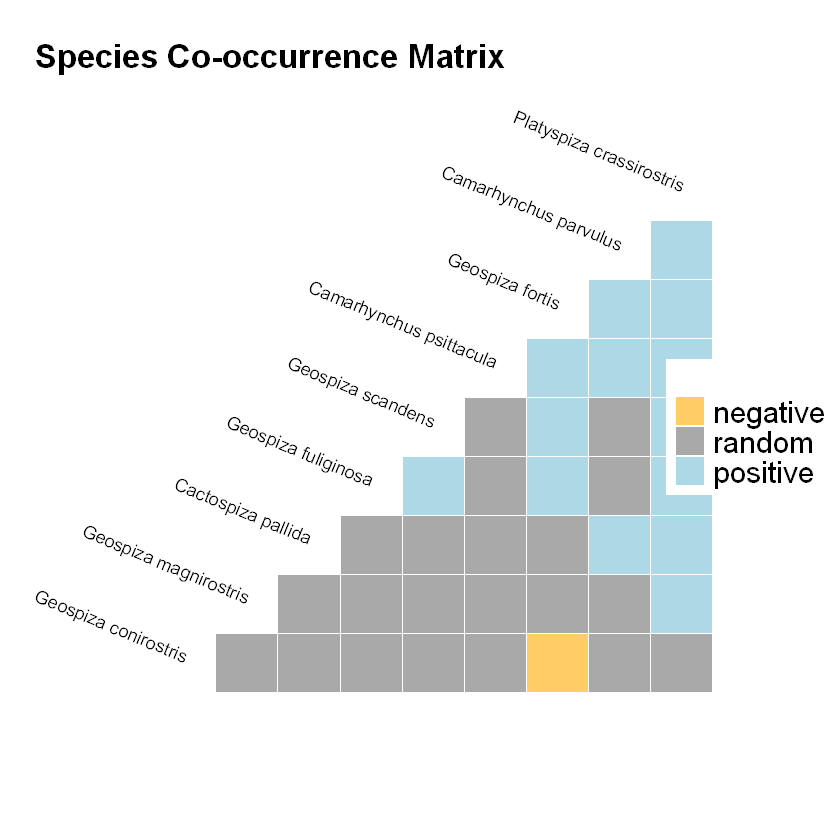

In [60]:
plot(result)  # plot species pairwise co-occurrence patterns

In [61]:
prob.table(result)[1:5, ]  # pairwise co-occurrence probabilities: obs/exp counts and p-values for each species pair

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,1,2,14,13,11,0.630,10.7,0.87941,0.57941,Geospiza magnirostris,Geospiza fortis
2,1,3,14,14,11,0.678,11.5,0.53529,1.00000,Geospiza magnirostris,Geospiza fuliginosa
3,1,4,14,10,10,0.484,8.2,1.00000,0.05147,Geospiza magnirostris,Geospiza difficilis
4,1,5,14,12,10,0.581,9.9,0.80882,0.67647,Geospiza magnirostris,Geospiza scandens
5,1,6,14,2,1,0.097,1.6,0.33088,0.97794,Geospiza magnirostris,Geospiza conirostris


In [62]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result)[order(prob.table(result)$p_lt), ][1:5, ]
prob.table(result)[order(prob.table(result)$p_gt), ][1:5, ]

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
15,2,6,13,2,0,0.090,1.5,0.04412,1,Geospiza fortis,Geospiza conirostris
39,5,6,12,2,0,0.083,1.4,0.07353,1,Geospiza scandens,Geospiza conirostris
48,6,10,2,11,0,0.076,1.3,0.11029,1,Geospiza conirostris,Platyspiza crassirostris
46,6,7,2,10,0,0.069,1.2,0.15441,1,Geospiza conirostris,Camarhynchus psittacula
47,6,9,2,10,0,0.069,1.2,0.15441,1,Geospiza conirostris,Camarhynchus parvulus


Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
51,7,10,10,11,10,0.381,6.5,1.00000,0.00057,Camarhynchus psittacula,Platyspiza crassirostris
56,9,10,10,11,10,0.381,6.5,1.00000,0.00057,Camarhynchus parvulus,Platyspiza crassirostris
14,2,5,13,12,12,0.540,9.2,1.00000,0.00210,Geospiza fortis,Geospiza scandens
50,7,9,10,10,9,0.346,5.9,0.99995,0.00365,Camarhynchus psittacula,Camarhynchus parvulus
12,2,3,13,14,13,0.630,10.7,1.00000,0.00588,Geospiza fortis,Geospiza fuliginosa


In [63]:
pair.attributes(result) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,9.09,0.00,90.91,1,0,10,Geospiza magnirostris
6,45.45,9.09,45.45,5,1,5,Geospiza fortis
7,27.27,0.00,72.73,3,0,8,Geospiza fuliginosa
8,0.00,0.00,100.00,0,0,11,Geospiza difficilis
9,27.27,0.00,72.73,3,0,8,Geospiza scandens
10,0.00,11.11,88.89,0,1,8,Geospiza conirostris
11,27.27,0.00,72.73,3,0,8,Camarhynchus psittacula
12,0.00,0.00,100.00,0,0,1,Camarhynchus pauper
13,36.36,0.00,63.64,4,0,7,Camarhynchus parvulus


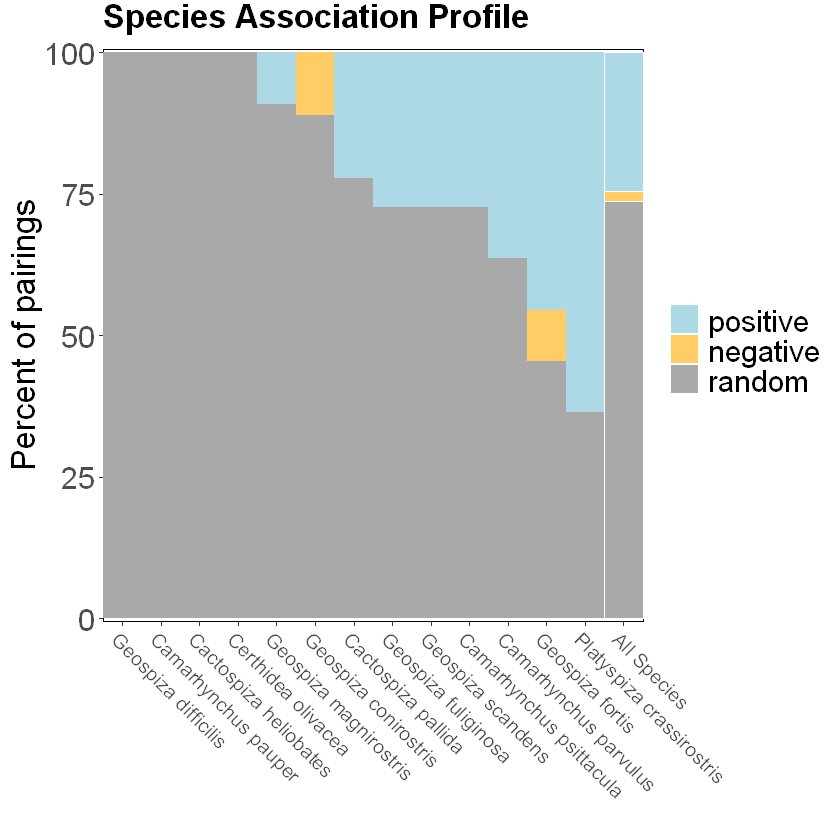

In [64]:
pair.profile(result) # species interaction profile visualization

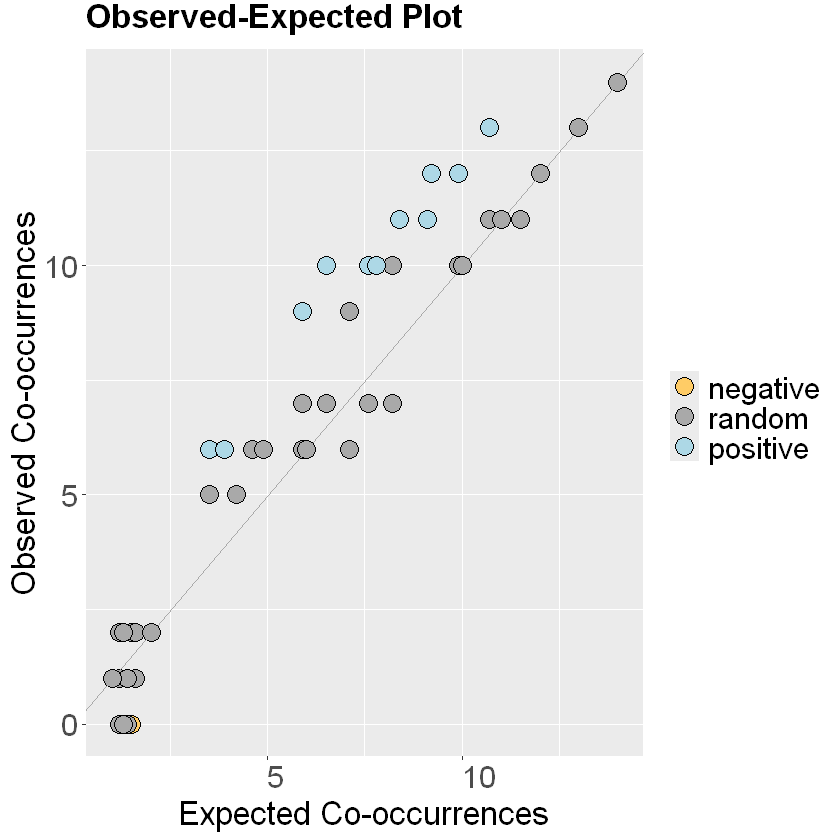

In [65]:
obs.v.exp(result) # observed vs expected co-occurrence comparison

In [68]:
round(effect.sizes(result,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

                         Geospiza magnirostris Geospiza fortis
Geospiza fortis                          0.018                
Geospiza fuliginosa                     -0.029           0.135
Geospiza difficilis                      0.106          -0.035
Geospiza scandens                        0.006           0.165
Geospiza conirostris                    -0.035          -0.088
Camarhynchus psittacula                  0.106           0.141
Camarhynchus pauper                         NA              NA
Camarhynchus parvulus                    0.106           0.141
Platyspiza crassirostris                 0.112           0.153
Cactospiza pallida                       0.065           0.082
Cactospiza heliobates                    0.024           0.029
Certhidea olivacea                       0.000           0.000
                         Geospiza fuliginosa Geospiza difficilis
Geospiza fortis                                                 
Geospiza fuliginosa                                

In [70]:
pair(mod = result, "Geospiza fortis", all=TRUE)  # pairwise stats for focal species

Species:
[1] "Geospiza fortis"
with 11 associations

                        sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur
12      Geospiza fuliginosa      14          13        0.630        10.7
13      Geospiza difficilis      10           7        0.450         7.6
14        Geospiza scandens      12          12        0.540         9.2
15     Geospiza conirostris       2           0        0.090         1.5
16  Camarhynchus psittacula      10          10        0.450         7.6
17    Camarhynchus parvulus      10          10        0.450         7.6
18 Platyspiza crassirostris      11          11        0.495         8.4
19       Cactospiza pallida       6           6        0.270         4.6
20    Cactospiza heliobates       2           2        0.090         1.5
21       Certhidea olivacea      17          13        0.765        13.0
1     Geospiza magnirostris      14          11        0.630        10.7
      p_lt    p_gt
12 1.00000 0.00588
13 0.44118 0.91176
14 1.00000 0.0

# Pre-carp analysis ($\leq 2007$)

In [6]:
library(cooccur)

############################
# load data
############################
df <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df[1,2:ncol(df)] <= 2007)+1 # before breakpoint
df <- df[,c(1,ind)]
colnames(df) <- paste(colnames(df), df[1, ], sep = "_")
df <- df[3:nrow(df), ]
rownames(df) <- df[,1]  
df <- df[, -1]

df <- df[rowSums(df) > 0, ] # remove species with no occurrences
print(dim(df))
print(df[1:5, 1:5])

df <- df[, colSums(df) >= 21]    # reduces site count
df <- df[rowSums(df) >= 0.05*ncol(df), ]   # reduces species count
print(dim(df))

[1]   87 1040
     A10A.RS_1997 A10A.RS.1_2003 A12A.RS_1995 A12A.RS.1_2002 A6A.RS_2003
AMEL            0              0            0              0           0
BHCP            0              0            0              0           0
BHMW            0              0            0              0           0
BKBF            0              0            0              0           0
BKBH            0              0            0              0           0
[1]  56 174


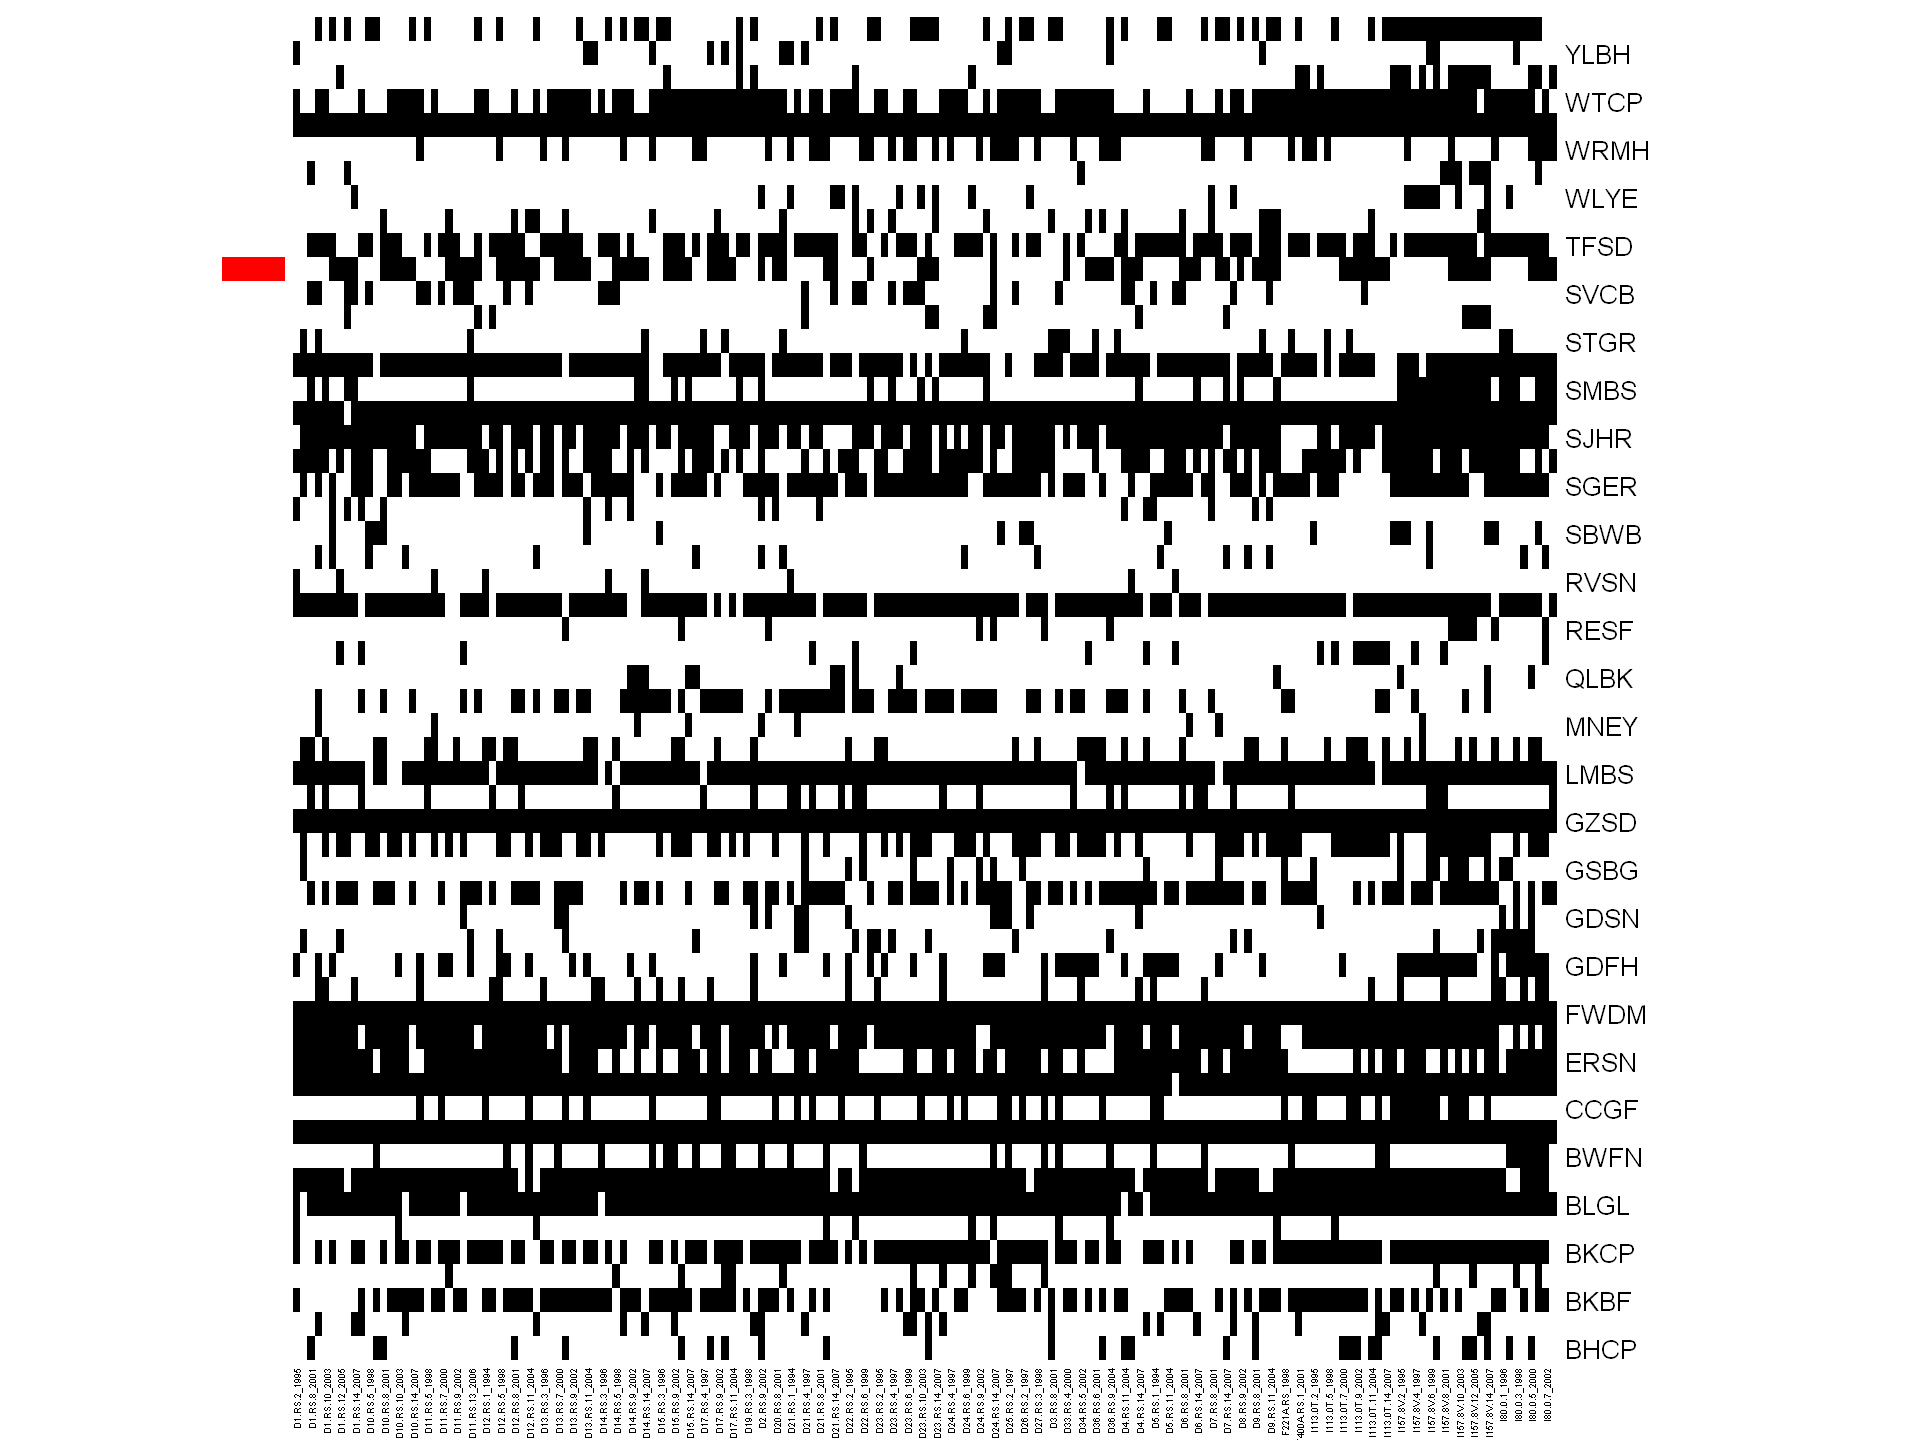

In [7]:
row_colors <- ifelse(rownames(df) == "SVCP", "red", "white")
options(repr.plot.width = 16, repr.plot.height = 12)
heatmap(as.matrix(df), col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA, cexRow = 2.0, margins = c(5, 10),
        RowSideColors = row_colors)

In [8]:
result <- cooccur(mat = df,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE,  # use species names
                   true_rand_classifier = 0.1)  # use a more stringent threshold for classifying random pairs (default is 0.5)

summary(result)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = df, type = "spp_site", thresh = TRUE, spp_names = TRUE, 
    true_rand_classifier = 0.1)

Of 1540 species pair combinations, 40 pairs (2.6 %) were removed from the analysis because expected co-occurrence was < 1 and 1500 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          56.0          174.0           71.0           52.0         1377.0 
Unclassifiable Non-random (%) 
           0.0            8.2 
attr(,"class")
[1] "summary.cooccur"

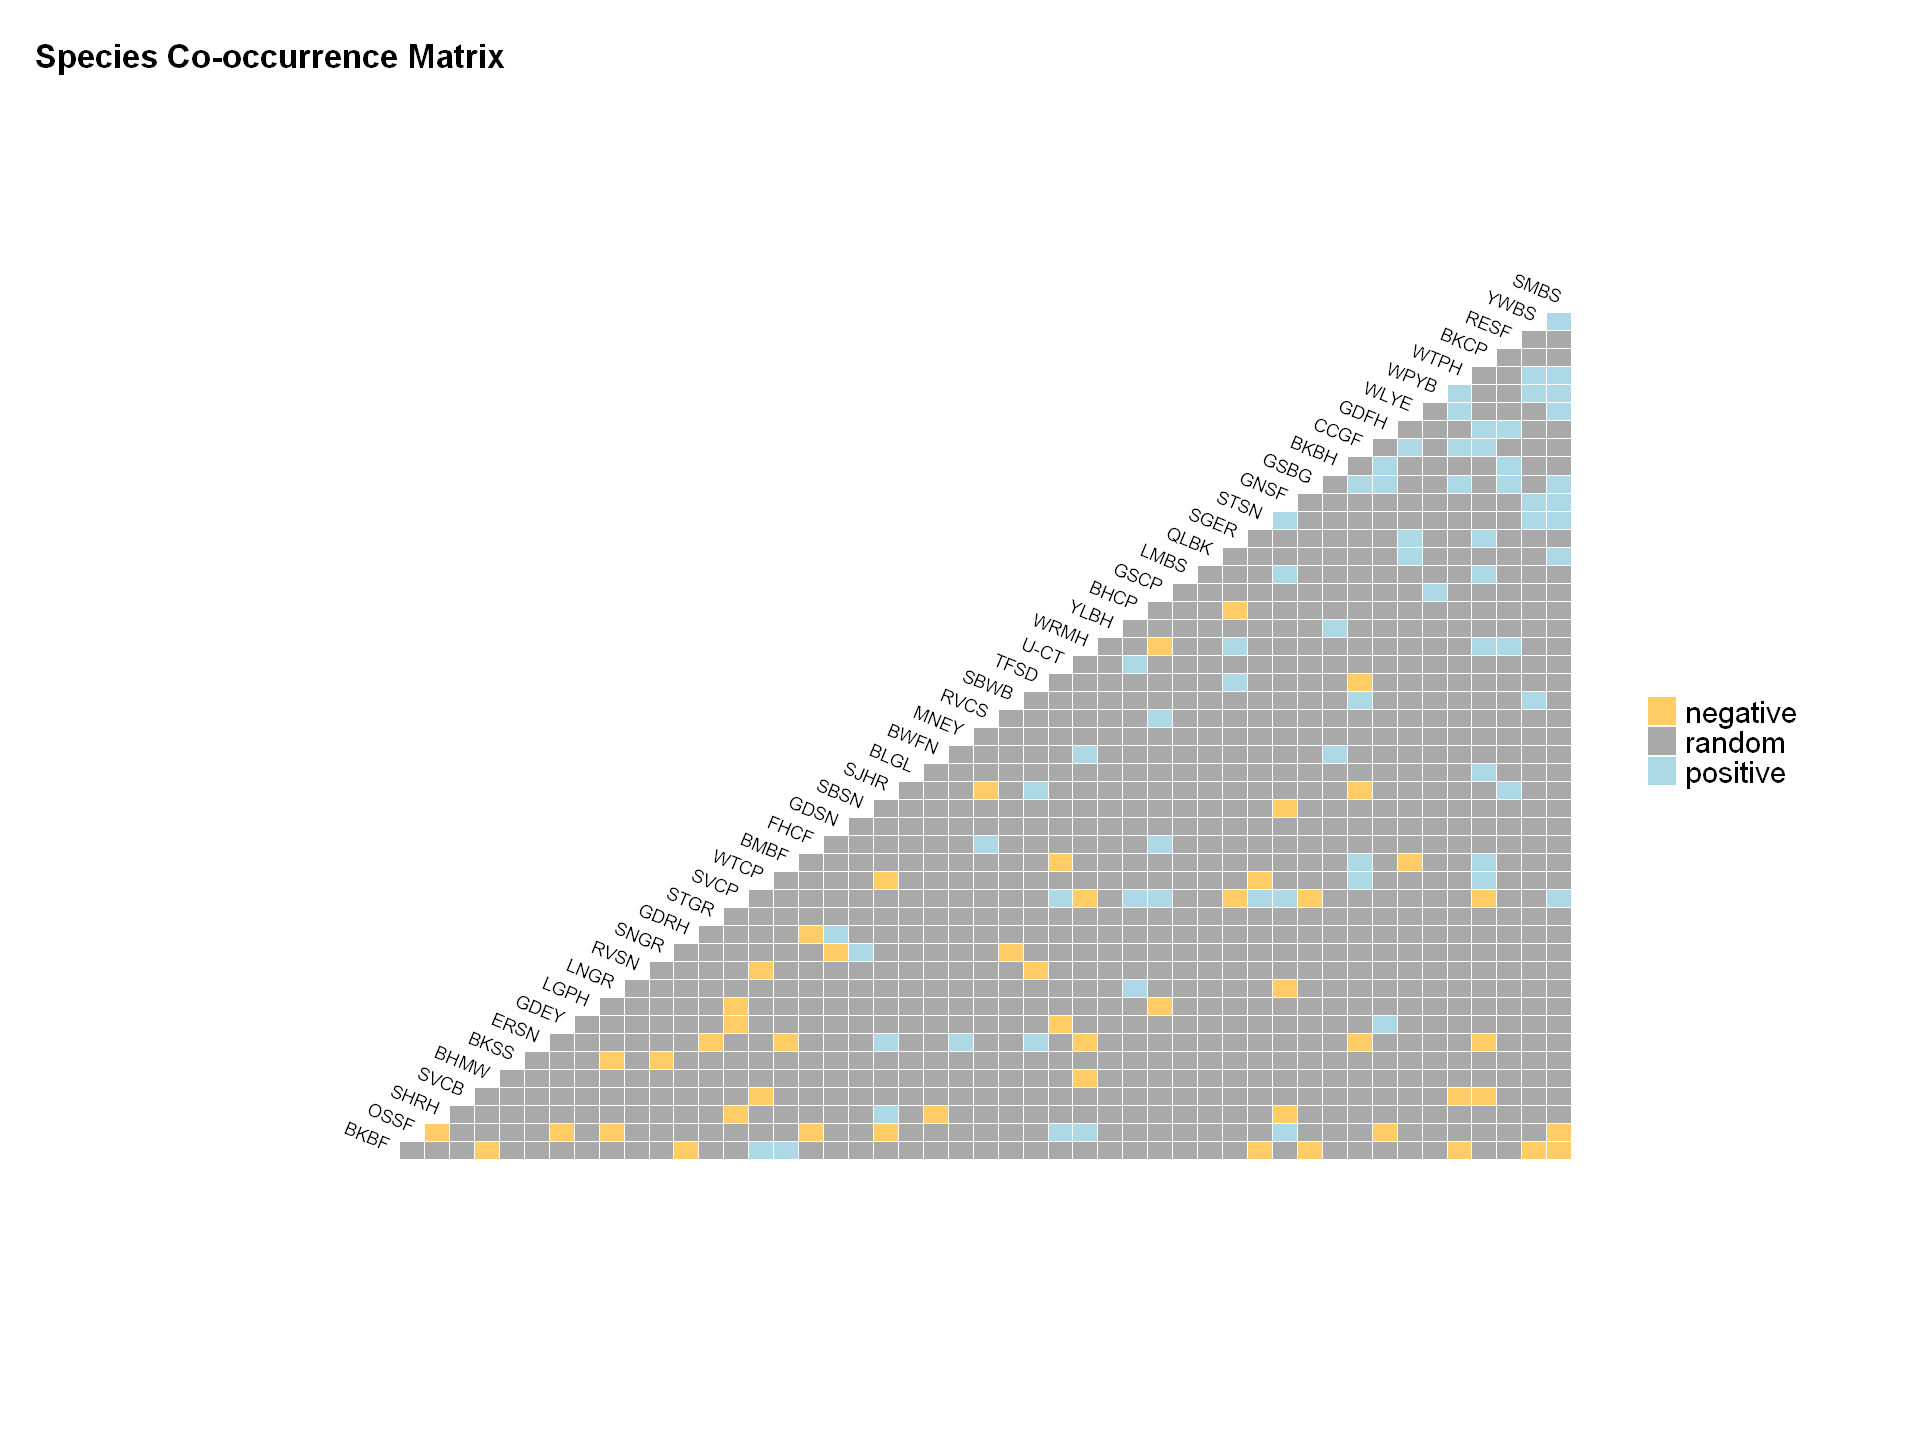

In [9]:
plot(result)  # plot species pairwise co-occurrence patterns

In [33]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result)[order(prob.table(result)$p_lt), ][1:10, ]
prob.table(result)[order(prob.table(result)$p_gt), ][1:10, ]

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1321,37,46,122,83,45,0.334,58.2,0.00001,1.00000,SGER,SVCP
1443,45,53,35,117,13,0.135,23.5,0.00004,0.99999,SVCB,WTCP
150,3,44,101,14,2,0.047,8.1,0.00065,0.99994,BKBF,STSN
124,3,18,101,25,7,0.083,14.5,0.00109,0.99978,BKBF,GDRH
935,22,24,87,29,7,0.083,14.5,0.00191,0.99956,GSCP,LGPH
147,3,41,101,40,15,0.133,23.2,0.00250,0.99924,BKBF,SMBS
162,3,56,101,69,31,0.230,40.1,0.00363,0.99865,BKBF,YWBS
962,22,51,87,44,14,0.126,22.0,0.00422,0.99861,GSCP,WRMH
1022,24,46,29,83,7,0.080,13.8,0.00434,0.99889,LGPH,SVCP


Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1391,41,50,40,10,9,0.013,2.3,1.00000,0.00001,SMBS,WPYB
1397,41,56,40,69,28,0.091,15.9,1.00000,0.00001,SMBS,YWBS
45,1,46,28,83,23,0.077,13.4,0.99999,0.00006,BHCP,SVCP
259,5,53,127,117,96,0.491,85.4,0.99996,0.00015,BKCP,WTCP
1395,41,54,40,23,13,0.030,5.3,0.99997,0.00018,SMBS,WTPH
1390,41,49,40,21,12,0.028,4.8,0.99995,0.00031,SMBS,WLYE
1499,54,56,23,69,17,0.052,9.1,0.99993,0.00040,WTPH,YWBS
1484,50,54,10,23,6,0.008,1.3,0.99997,0.00042,WPYB,WTPH
1322,37,47,122,114,90,0.459,79.9,0.99986,0.00049,SGER,TFSD


In [11]:
pair.attributes(result) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,5.45,1.82,92.73,3,1,51,BHCP
12,0.00,3.64,96.36,0,2,53,BHMW
23,3.64,12.73,83.64,2,7,46,BKBF
34,7.69,0.00,92.31,4,0,48,BKBH
45,14.55,5.45,80.00,8,3,44,BKCP
53,0.00,4.08,95.92,0,2,47,BKSS
54,1.82,0.00,98.18,1,0,54,BLGL
55,5.45,5.45,89.09,3,3,49,BMBF
56,3.64,1.82,94.55,2,1,52,BWFN


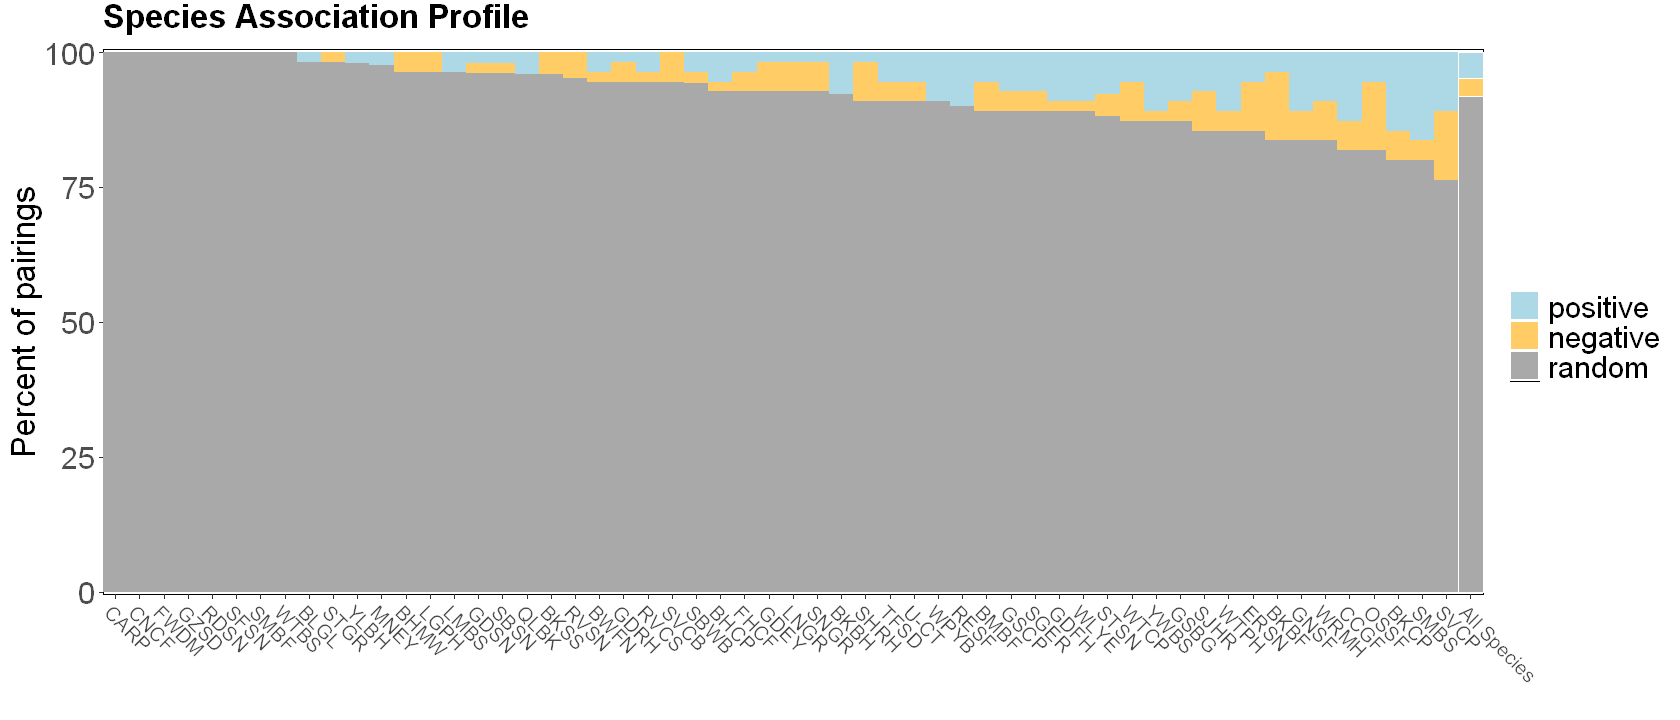

In [12]:
options(repr.plot.width = 14, repr.plot.height = 6)
pair.profile(result)

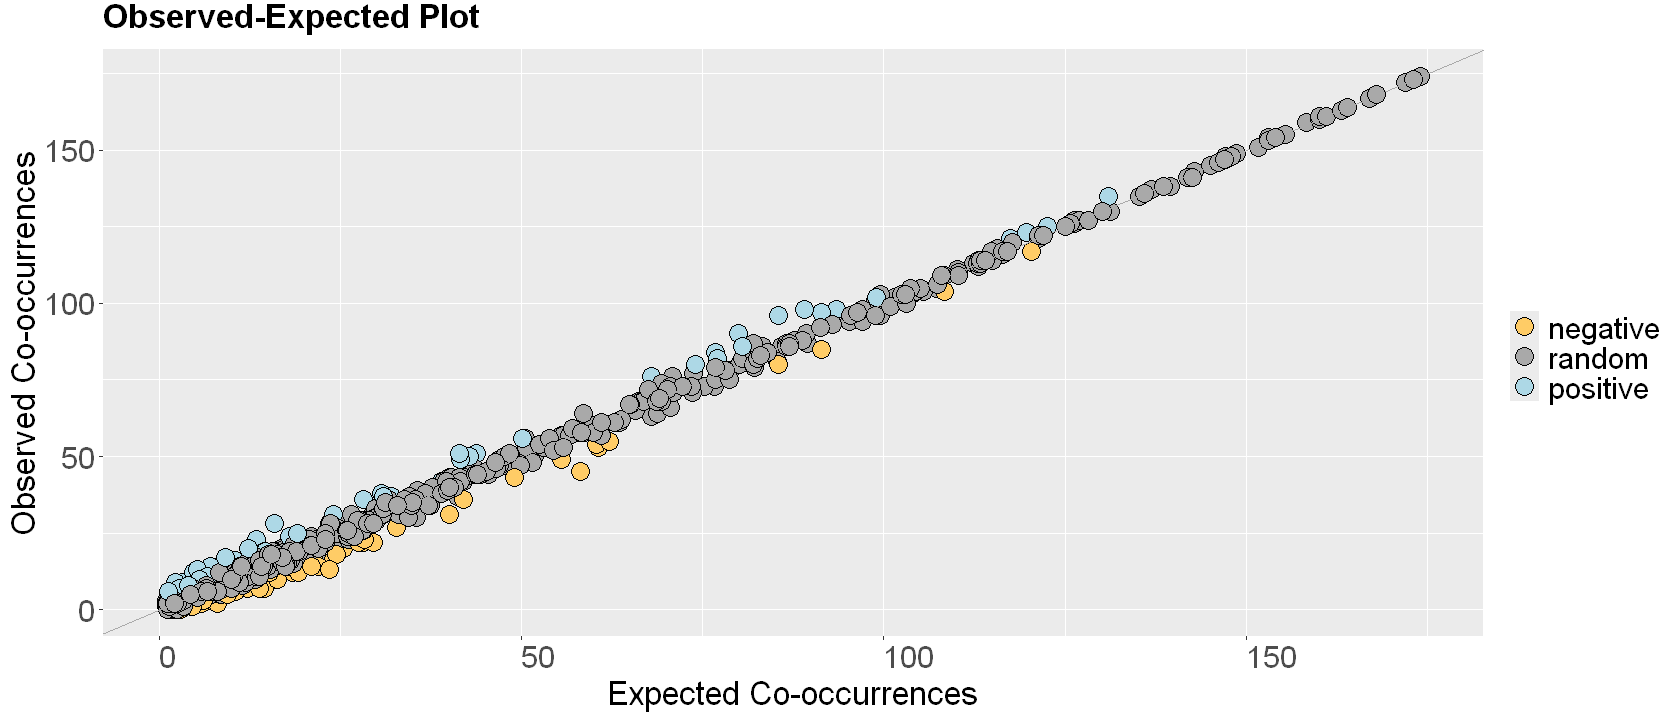

In [13]:
obs.v.exp(result) # observed vs expected co-occurrence comparison

In [14]:
round(effect.sizes(result,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

       BHCP   BHMW   BKBF   BKBH   BKCP   BKSS   BLGL   BMBF   BWFN   CARP
BHMW  0.010                                                               
BKBF -0.007 -0.033                                                        
BKBH  0.007 -0.003 -0.017                                                 
BKCP -0.008  0.007  0.019  0.009                                          
BKSS -0.005 -0.004 -0.008  0.005  0.000                                   
BLGL  0.000 -0.006 -0.003  0.003  0.014  0.002                            
BMBF  0.006  0.006  0.026  0.002  0.020 -0.007 -0.002                     
BWFN  0.011 -0.005  0.006  0.023 -0.003  0.011  0.001  0.002              
CARP  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000       
CCGF  0.013 -0.014  0.015 -0.001  0.042 -0.010  0.008  0.018 -0.003  0.000
CNCF  0.001  0.001 -0.002  0.001 -0.002  0.001  0.000 -0.001  0.001  0.000
ERSN -0.010  0.005 -0.028  0.003 -0.031  0.009 -0.006 -0.025 -0.016  0.000
FHCF  0.007  0.006  0.001

In [15]:
pair(mod = result, "SVCP", all=TRUE)  # pairwise stats for focal species

Species:
[1] "SVCP"
with 55 associations

      sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur    p_lt    p_gt
1447 TFSD     114          52        0.313        54.4 0.27414 0.82107
1448 U-CT      26          20        0.071        12.4 0.99978 0.00109
1449 WLYE      21           7        0.058        10.0 0.12001 0.95075
1450 WPYB      10           7        0.027         4.8 0.96401 0.12963
1451 WRMH      44          14        0.121        21.0 0.01124 0.99586
1452 WTBS     174          83        0.477        83.0 1.00000 1.00000
1453 WTCP     117          53        0.321        55.8 0.22745 0.85781
1454 WTPH      23          11        0.063        11.0 0.59434 0.58243
1455 YLBH      17           6        0.047         8.1 0.20607 0.90991
1456 YWBS      69          34        0.189        32.9 0.68875 0.42769
45   BHCP      28          23        0.077        13.4 0.99999 0.00006
99   BHMW      27          14        0.074        12.9 0.75166 0.39677
152  BKBF     101          49      

# Post-carp analysis ($> 2007$)

In [ ]:
library(cooccur)

############################
# load data
############################
df2 <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df2[1,2:ncol(df2)] > 2007)+1 # before breakpoint
df2 <- df2[,c(1,ind)]
colnames(df2) <- paste(colnames(df2), df2[1, ], sep = "_")
df2 <- df2[3:nrow(df2), ]
rownames(df2) <- df2[,1]  
df2 <- df2[, -1]

df2 <- df2[rowSums(df2) > 0, ] # remove species with no occurrences
print(dim(df2))
print(df2[1:5, 1:5])

df2 <- df2[, colSums(df2) >= 23]    # reduces site count
df2 <- df2[rowSums(df2) >= 0.05*ncol(df2), ]   # reduces species count
print(dim(df2))

[1]  103 1261
     A11A.RS_2015 A13A.RS_2024 A14A.RS_2011 A19A.RS_2022 A22A.RS_2011
AMEL            0            0            0            0            0
BDKF            0            0            0            0            0
BGOS            0            0            0            0            0
BGRS            0            0            0            0            0
BGWM            0            0            0            0            0
[1]  51 365


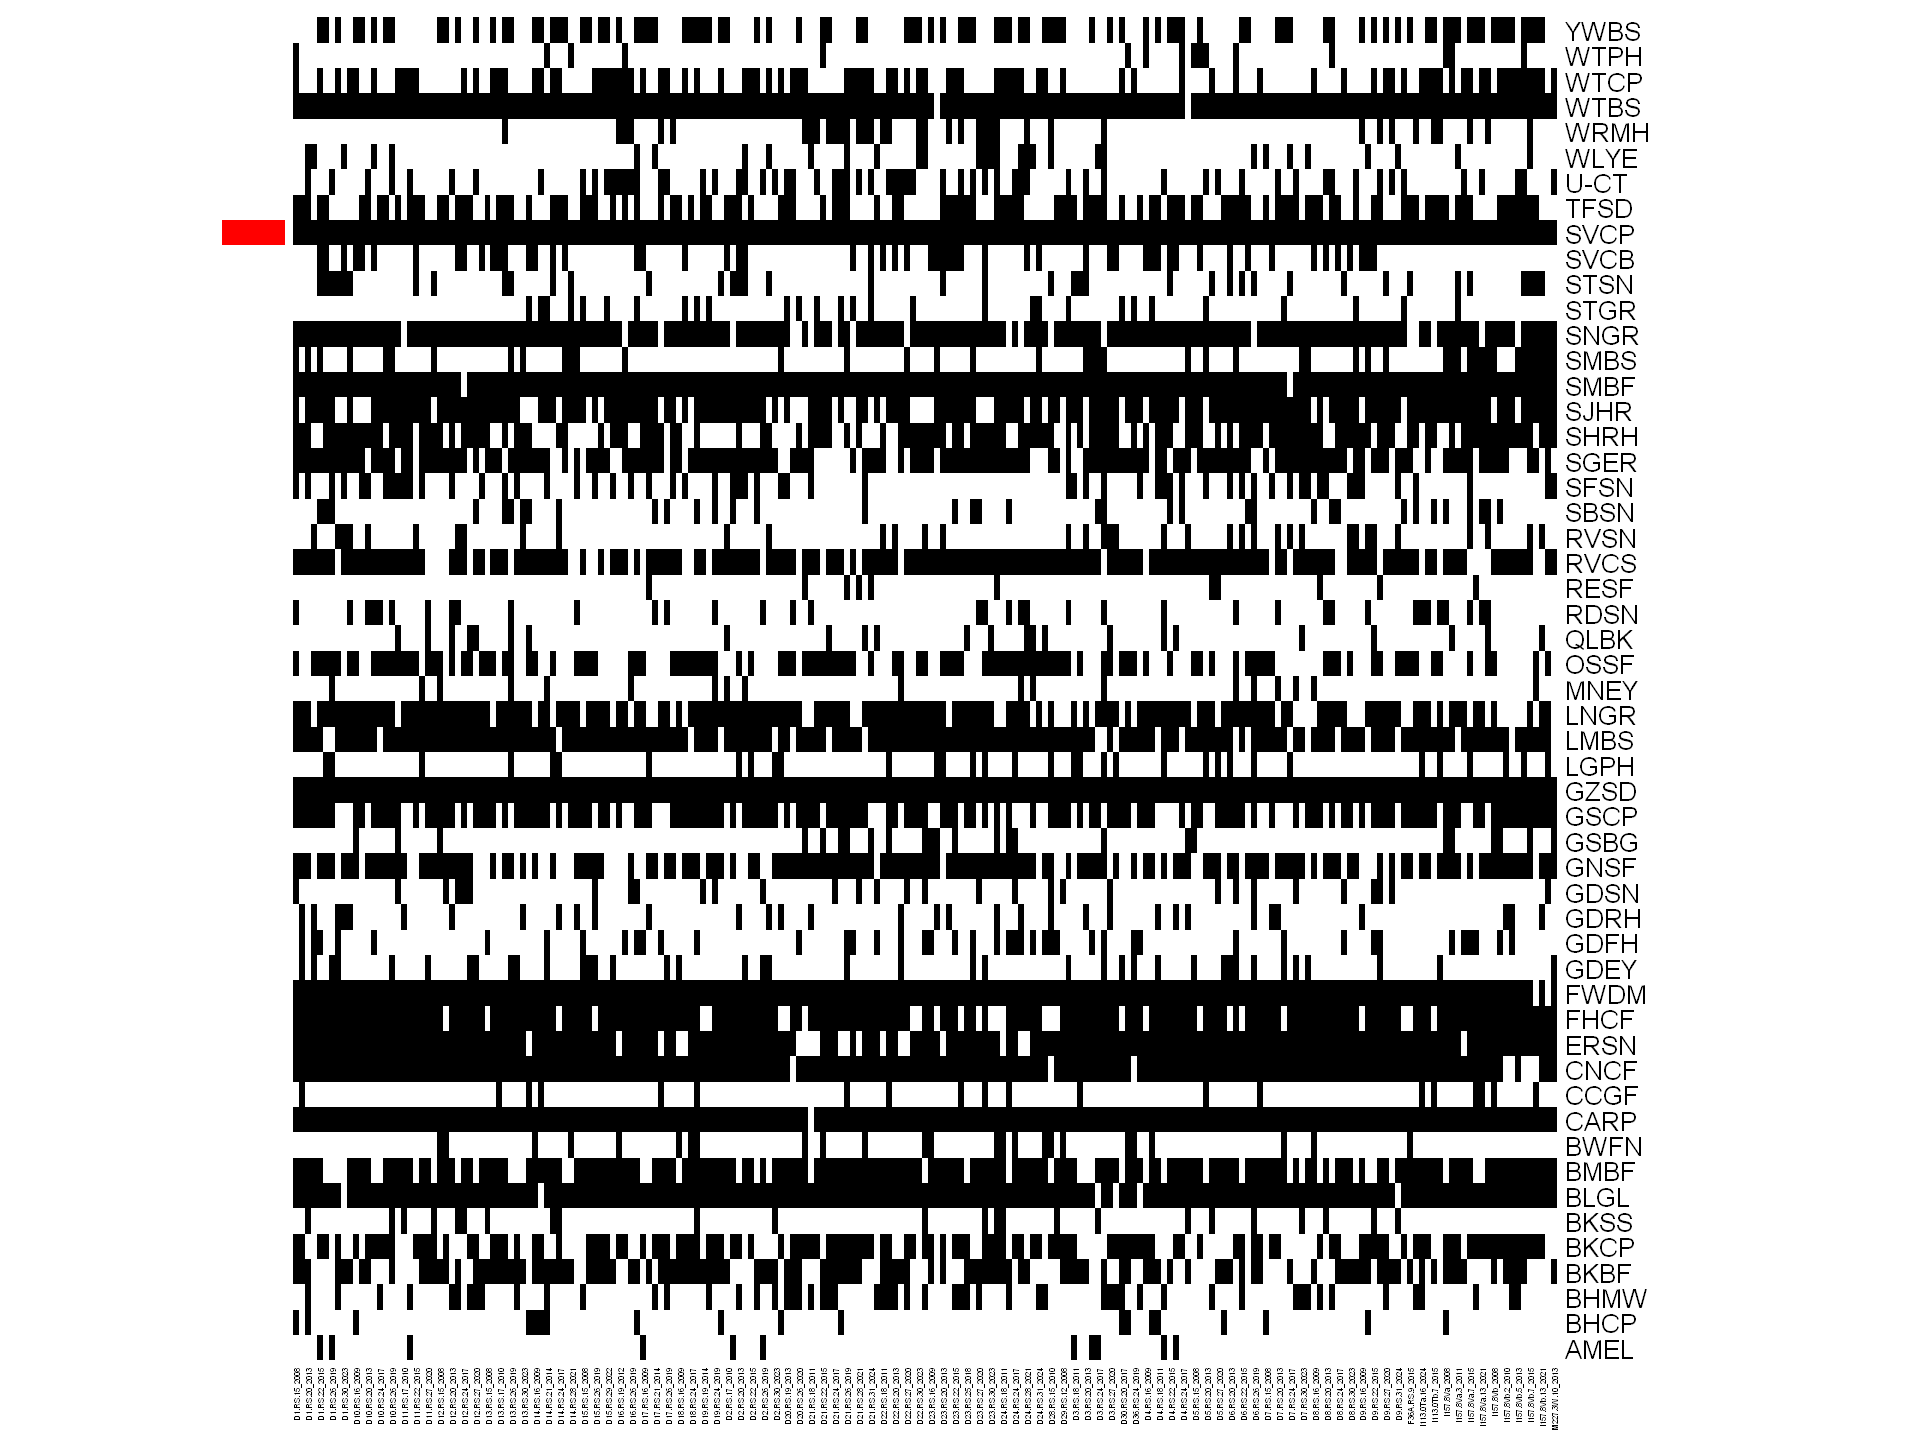

In [22]:
row_colors <- ifelse(rownames(df2) == "SVCP", "red", "white")
options(repr.plot.width = 16, repr.plot.height = 12)
heatmap(as.matrix(df2), col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA, cexRow = 2.0, margins = c(5, 10),
        RowSideColors = row_colors)

In [24]:
result2 <- cooccur(mat = df2,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE,  # use species names
                   true_rand_classifier = 0.1)  # use a more stringent threshold for classifying random pairs (default is 0.5)

summary(result2)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = df2, type = "spp_site", thresh = TRUE, spp_names = TRUE, 
    true_rand_classifier = 0.1)

Of 1378 species pair combinations, 7 pairs (0.51 %) were removed from the analysis because expected co-occurrence was < 1 and 1371 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          53.0          211.0           58.0           61.0         1252.0 
Unclassifiable Non-random (%) 
           0.0            8.7 
attr(,"class")
[1] "summary.cooccur"

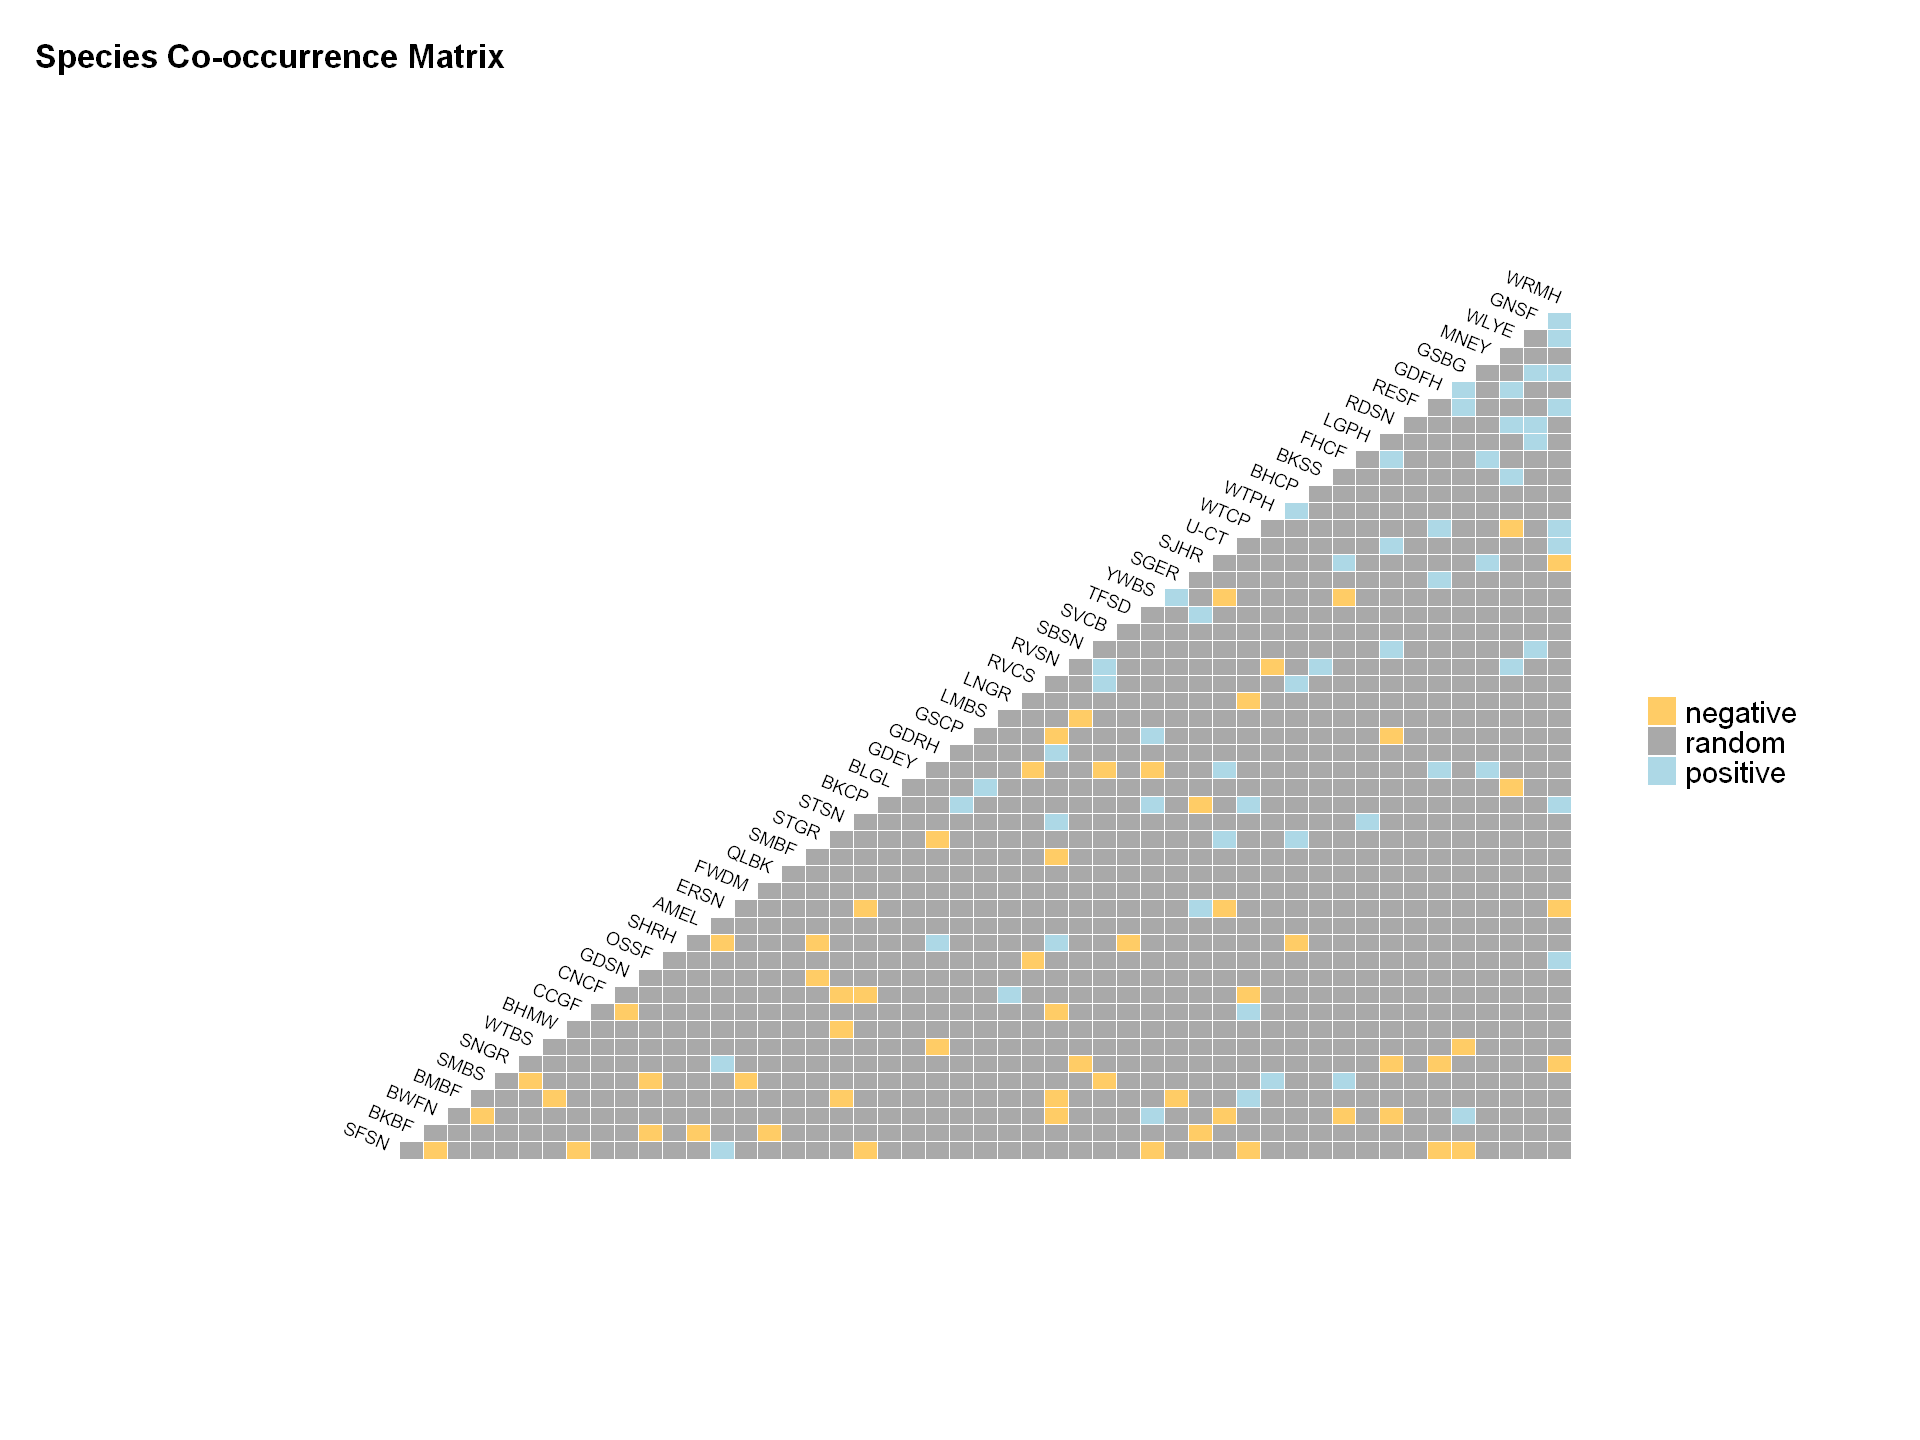

In [25]:
plot(result2)  # plot species pairwise co-occurrence patterns

In [32]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result2)[order(prob.table(result2)$p_lt), ][1:10, ]
prob.table(result2)[order(prob.table(result2)$p_gt), ][1:10, ]

Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
725,17,35,45,60,4,0.061,12.8,0.00046,0.99992,GDFH,SFSN
589,13,49,191,38,28,0.163,34.4,0.00057,0.99991,ERSN,WRMH
1218,35,53,60,97,17,0.131,27.6,0.00089,0.99971,SFSN,YWBS
227,5,35,127,60,26,0.171,36.1,0.00144,0.99950,BKCP,SFSN
409,9,35,25,60,1,0.034,7.1,0.00160,0.99988,BWFN,SFSN
1216,35,51,60,91,16,0.123,25.9,0.00169,0.99943,SFSN,WTCP
373,8,43,166,40,24,0.149,31.5,0.00217,0.99941,BMBF,STSN
82,2,37,19,136,6,0.058,12.2,0.00238,0.99954,BHCP,SHRH
363,8,33,166,38,23,0.142,29.9,0.00377,0.99893,BMBF,RVSN


Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
957,24,43,34,40,16,0.031,6.4,0.99999,0.00003,LGPH,STSN
243,5,51,127,91,67,0.260,54.8,0.99987,0.00039,BKCP,WTCP
822,20,30,151,38,35,0.129,27.2,0.99987,0.00086,GNSF,RDSN
813,20,21,151,25,24,0.085,17.9,0.99988,0.00160,GNSF,GSBG
758,18,33,34,38,13,0.029,6.1,0.99958,0.00181,GDRH,RVSN
681,16,27,40,19,9,0.017,3.6,0.99947,0.00292,GDEY,MNEY
1171,33,43,38,40,14,0.034,7.2,0.99915,0.00318,RVSN,STSN
1357,48,49,32,38,12,0.027,5.8,0.99911,0.00358,WLYE,WRMH
214,5,22,127,144,96,0.411,86.7,0.99844,0.00396,BKCP,GSCP


In [27]:
pair.attributes(result2) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,0.00,2.08,97.92,0,1,47,AMEL
12,6.00,2.00,92.00,3,1,46,BHCP
23,0.00,3.85,96.15,0,2,50,BHMW
34,0.00,7.69,92.31,0,4,48,BKBF
45,7.69,7.69,84.62,4,4,44,BKCP
50,3.85,0.00,96.15,2,0,50,BKSS
51,1.92,1.92,96.15,1,1,50,BLGL
52,1.92,7.69,90.38,1,4,47,BMBF
53,3.85,11.54,84.62,2,6,44,BWFN


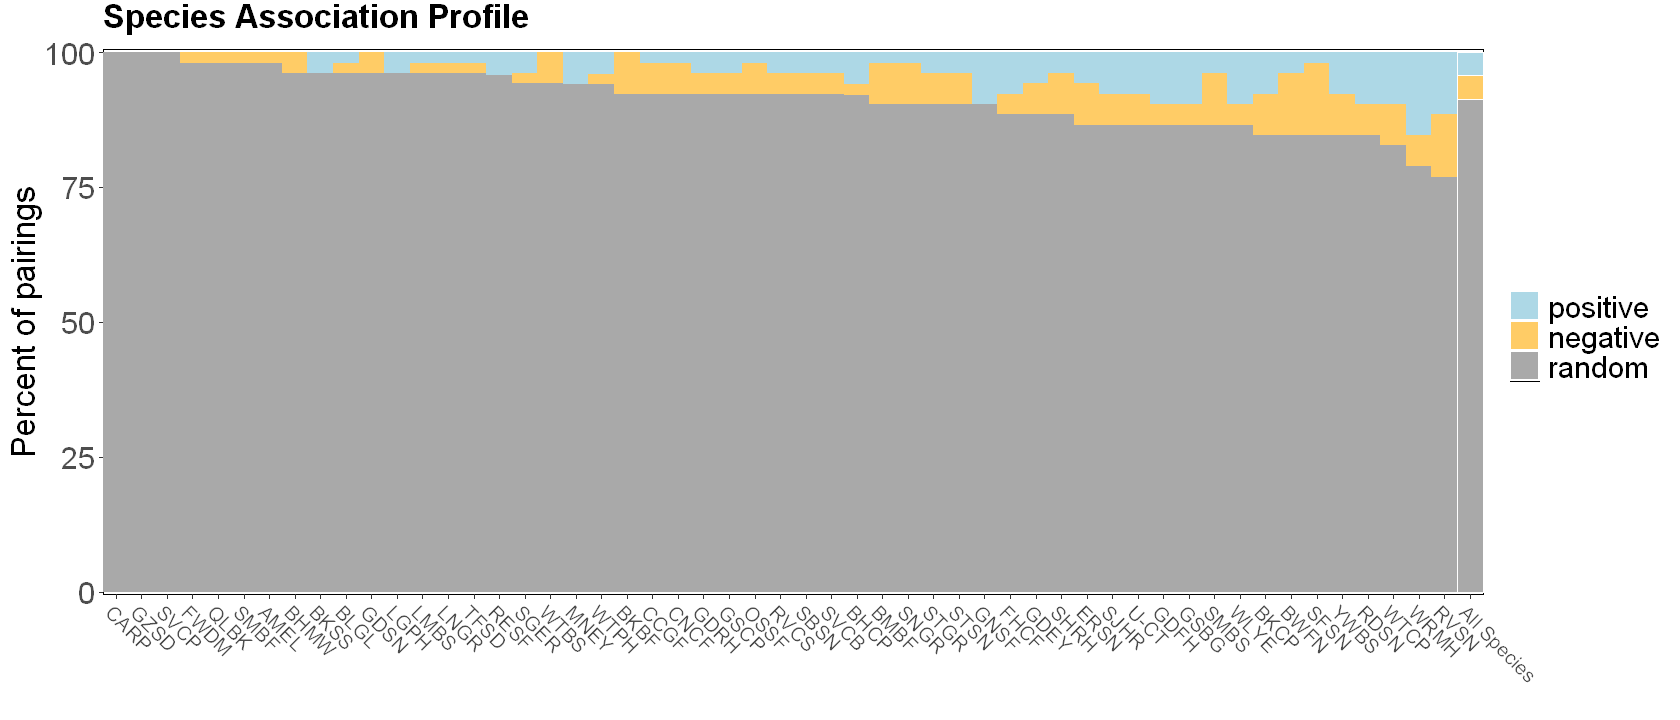

In [28]:
options(repr.plot.width = 14, repr.plot.height = 6)
pair.profile(result2)

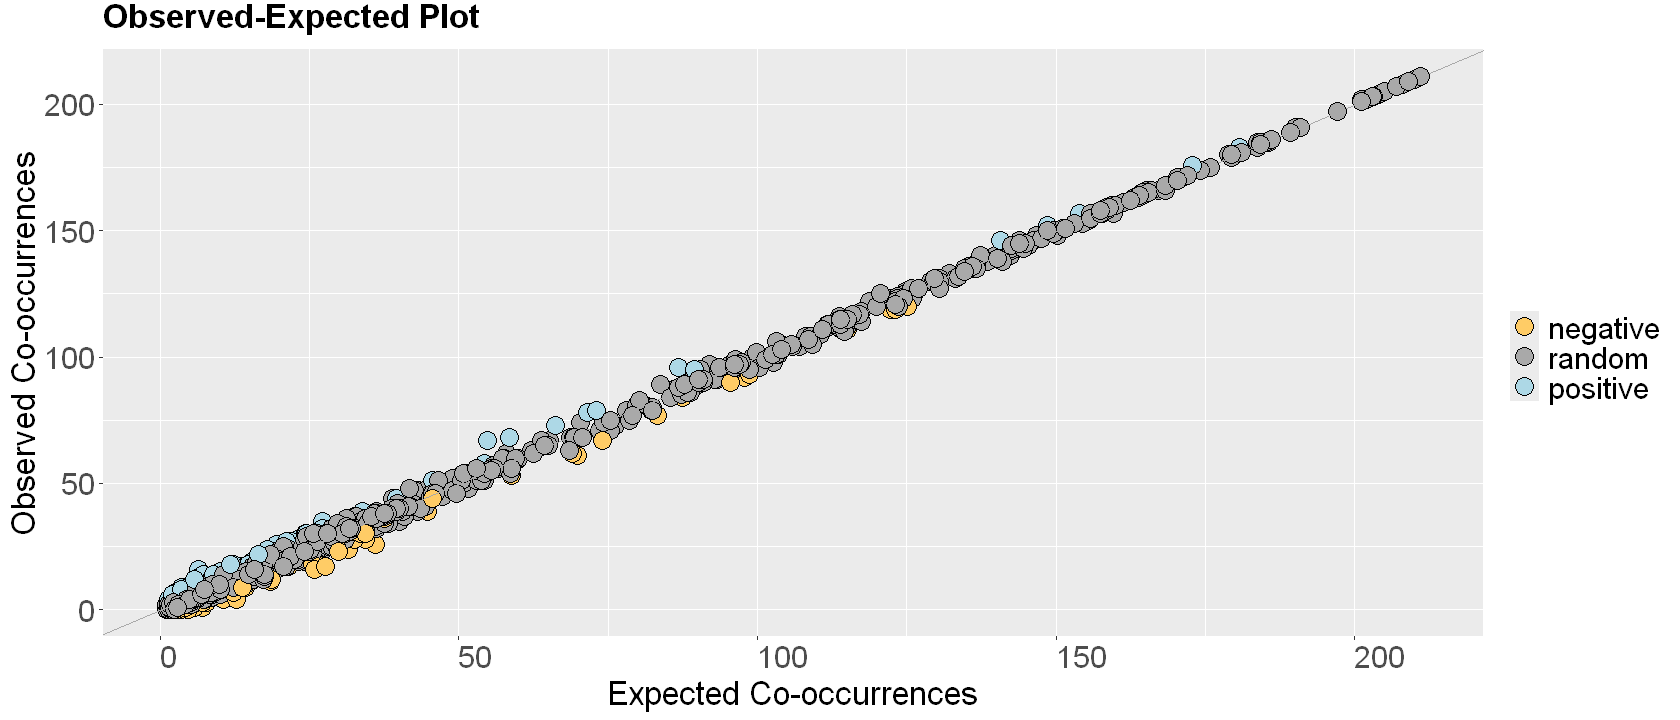

In [29]:
obs.v.exp(result2) # observed vs expected co-occurrence comparison

In [30]:
round(effect.sizes(result2,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

       AMEL   BHCP   BHMW   BKBF   BKCP   BKSS   BLGL   BMBF   BWFN   CARP
BHCP     NA                                                               
BHMW -0.005 -0.010                                                        
BKBF -0.022  0.018 -0.014                                                 
BKCP -0.008  0.003  0.003 -0.013                                          
BKSS -0.001 -0.006 -0.002  0.003 -0.016                                   
BLGL -0.003 -0.002 -0.002  0.003  0.003 -0.006                            
BMBF -0.008  0.005 -0.027  0.004  0.010  0.000 -0.001                     
BWFN -0.006  0.003 -0.018  0.005  0.014  0.006  0.003  0.006              
CARP  0.000  0.000 -0.003  0.003 -0.002  0.000  0.000  0.004  0.000       
CCGF -0.005  0.001 -0.002  0.010  0.014 -0.001 -0.002 -0.003 -0.007  0.000
CNCF  0.002  0.003  0.001  0.004 -0.015  0.004 -0.001 -0.003 -0.005  0.000
ERSN  0.005 -0.001  0.007 -0.015 -0.019  0.006 -0.003 -0.011 -0.008  0.004
FHCF  0.008  0.003  0.005

In [31]:
pair(mod = result2, "SVCP", all=TRUE)  # pairwise stats for focal species

Species:
[1] "SVCP"
with 52 associations

      sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur p_lt p_gt
1336 TFSD     115         115        0.545         115    1    1
1337 U-CT      65          65        0.308          65    1    1
1338 WLYE      32          32        0.152          32    1    1
1339 WRMH      38          38        0.180          38    1    1
1340 WTBS     209         209        0.991         209    1    1
1341 WTCP      91          91        0.431          91    1    1
1342 WTPH      16          16        0.076          16    1    1
1343 YWBS      97          97        0.460          97    1    1
41   AMEL      11          11        0.052          11    1    1
90   BHCP      19          19        0.090          19    1    1
140  BHMW      57          57        0.270          57    1    1
189  BKBF     126         126        0.597         126    1    1
237  BKCP     127         127        0.602         127    1    1
284  BKSS      24          24        0.114      